In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from datasets import load_dataset, DatasetDict

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("mteb/imdb")

# ds = DatasetDict({
#     "train": ds["train"].shuffle(seed=42).select(range(500)),
#     "test": ds["test"].shuffle(seed=42).select(range(200)),
# })

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/20.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24904 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24678 [00:00<?, ? examples/s]

In [3]:
ds["train"].features['label']

Value('int64')

In [4]:
from transformers import pipeline, AutoTokenizer, AutoModelForMaskedLM, AutoModelForSequenceClassification

# model_name = "FacebookAI/roberta-base"

# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=2
# )

# tokenizer = AutoTokenizer.from_pretrained(model_name)
# #model = AutoModelForMaskedLM.from_pretrained(model_name)

In [5]:
# def tokenize_function(example):
#     return tokenizer(example['text'], padding="max_length", truncation=True, max_length=512)

In [6]:
# tokenized_dataset = ds.map(tokenize_function, batched=True)

In [7]:
# tokenized_dataset = tokenized_dataset.remove_columns(["text"])
# tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
# tokenized_dataset.set_format("torch")

In [8]:
# train_valid = tokenized_dataset["train"].train_test_split(
#     test_size=0.1,
#     seed=42
# )


# train_ds = train_valid["train"]
# val_ds = train_valid["test"]
# test_ds = ds["test"]

In [9]:
from peft import LoraConfig, get_peft_model


def setup_config(rank, target_modules):
    config = LoraConfig(
        r=rank,
        lora_alpha=16,
        target_modules = target_modules,
        lora_dropout=0.1,
        bias='none',
        task_type="SEQ_CLS",
        modules_to_save=['classifier']
    )
    return config
    


In [10]:
model_ids = ["FacebookAI/roberta-base", "microsoft/deberta-v3-base", "distilbert/distilbert-base-uncased"]


for model_id in model_ids:
    temp_model = AutoModelForSequenceClassification.from_pretrained(model_id)
    
    # Print all module names
    for name, module in temp_model.named_modules():
        print(name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



roberta
roberta.embeddings
roberta.embeddings.word_embeddings
roberta.embeddings.token_type_embeddings
roberta.embeddings.LayerNorm
roberta.embeddings.dropout
roberta.embeddings.position_embeddings
roberta.encoder
roberta.encoder.layer
roberta.encoder.layer.0
roberta.encoder.layer.0.attention
roberta.encoder.layer.0.attention.self
roberta.encoder.layer.0.attention.self.query
roberta.encoder.layer.0.attention.self.key
roberta.encoder.layer.0.attention.self.value
roberta.encoder.layer.0.attention.self.dropout
roberta.encoder.layer.0.attention.output
roberta.encoder.layer.0.attention.output.dense
roberta.encoder.layer.0.attention.output.LayerNorm
roberta.encoder.layer.0.attention.output.dropout
roberta.encoder.layer.0.intermediate
roberta.encoder.layer.0.intermediate.dense
roberta.encoder.layer.0.intermediate.intermediate_act_fn
roberta.encoder.layer.0.output
roberta.encoder.layer.0.output.dense
roberta.encoder.layer.0.output.LayerNorm
roberta.encoder.layer.0.output.dropout
roberta.encod

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



distilbert
distilbert.embeddings
distilbert.embeddings.word_embeddings
distilbert.embeddings.position_embeddings
distilbert.embeddings.LayerNorm
distilbert.embeddings.dropout
distilbert.transformer
distilbert.transformer.layer
distilbert.transformer.layer.0
distilbert.transformer.layer.0.attention
distilbert.transformer.layer.0.attention.q_lin
distilbert.transformer.layer.0.attention.k_lin
distilbert.transformer.layer.0.attention.v_lin
distilbert.transformer.layer.0.attention.out_lin
distilbert.transformer.layer.0.attention.dropout
distilbert.transformer.layer.0.sa_layer_norm
distilbert.transformer.layer.0.ffn
distilbert.transformer.layer.0.ffn.dropout
distilbert.transformer.layer.0.ffn.lin1
distilbert.transformer.layer.0.ffn.lin2
distilbert.transformer.layer.0.ffn.activation
distilbert.transformer.layer.0.output_layer_norm
distilbert.transformer.layer.1
distilbert.transformer.layer.1.attention
distilbert.transformer.layer.1.attention.q_lin
distilbert.transformer.layer.1.attention.k_l

In [11]:
from transformers import TrainingArguments, Trainer
import time
import numpy as np
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import os


import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# config1 = setup_config(8, ["query", "value"])
# config2 = setup_config(16, ["query", "value"])
# config3 = setup_config(16, ["query", "value", 'fc1', 'fc2'])

# # lst_configs = [config1, config2, config3]

# configs_to_test = {
#     "lora_r8_qv": config1,
#     "lora_r16_qv": config2,
#     "lora_r16_qv_fc": config3
# }

def get_target_modules(model_id):
    model_id = model_id.lower()
    if "roberta" in model_id:
        return ["query", "value"]
    elif "deberta" in model_id:
        return ["query_proj", "value_proj"]
    elif "distilbert" in model_id:
        return ["q_lin", "v_lin"]
    else:
        # Default fallback for most BERT-like models
        return ["query", "value"]


def prepare_datasets(model_name, ds):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)
    
    tokenized_dataset = ds.map(tokenize_function, batched=True)
    
    cols_to_remove = [col for col in tokenized_dataset["train"].column_names if col not in ["input_ids", "attention_mask", "label"]]
    tokenized_dataset = tokenized_dataset.remove_columns(cols_to_remove)
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
    tokenized_dataset.set_format("torch")
    
    train_valid = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=42)
    
    train_ds = train_valid["train"]
    val_ds = train_valid["test"]
    test_ds = tokenized_dataset["test"] 

    return train_ds, val_ds, test_ds

# def load_model_and_dataset(model_name, ds):
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=2
#     )

#     tokenizer = AutoTokenizer.from_pretrained(model_name)
    
#     tokenized_dataset = ds.map(tokenize_function, batched=True)
#     tokenized_dataset = tokenized_dataset.remove_columns(["text"])
#     tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
#     tokenized_dataset.set_format("torch")
#     train_valid = tokenized_dataset["train"].train_test_split(
#         test_size=0.1,
#         seed=42
#     )
    
    
#     train_ds = train_valid["train"]
#     val_ds = train_valid["test"]
#     test_ds = dataset["test"]

#     return model, train_ds, val_ds, test_d





In [12]:
logs = []
def training_pipeline_lora(model_id, config, run_name,seed, train_ds, val_ds, test_ds):
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=2
    )
    set_seed(seed)

    print(f"--- Training Run: {run_name} ---")
    model = get_peft_model(base_model, config)
    model.print_trainable_parameters()
    
    batch_size = 16
    learning_rate = 1e-5

    safe_model_name = model_id.split("/")[-1]
    out_dir = f"./results/{safe_model_name}_{run_name}_seed{seed}"
    args = TrainingArguments(
        output_dir=out_dir,
        remove_unused_columns=False,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=4,
        per_device_eval_batch_size=batch_size,
        bf16=True,
        num_train_epochs=2,
        logging_steps=10,
        load_best_model_at_end=True,
        label_names=["labels"],
    )

    trainer = Trainer(
        model,
        args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
    )
    os.system("nvidia-smi")
    start = time.time()
    trainer.train()
    os.system("nvidia-smi")
    end = time.time()
    train_time = end - start
    if torch.cuda.is_available():
        peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 3)
    else:
        peak_vram = 0
    predictions = trainer.predict(test_ds)

    preds = np.argmax(predictions.predictions, axis=1)
    
    labels = predictions.label_ids
    
    acc = accuracy_score(labels, preds)
        
    f1 = f1_score(labels, preds, average="macro")

    print(f"[{run_name}] Accuracy: {acc:.4f}")
    print(f"[{run_name}] F1 Score: {f1:.4f}")
    print(f"[{run_name}] Training Time: {train_time:.2f} seconds\n")

    logs.append({
        "seed": seed,
        "rank": config.r,
        "lr": learning_rate,
        "run_name": run_name,
        "target": str(config.target_modules),
        "accuracy": acc,
        "f1": f1,
        "train_time": train_time,
        "vram": peak_vram
    })


    del model, trainer, base_model
    torch.cuda.empty_cache()


In [13]:
model_ids = ["FacebookAI/roberta-base", "microsoft/deberta-v3-base", "distilbert/distilbert-base-uncased"]


for model_id in model_ids:
    configs_to_test = {
        "lora_r8_qv": setup_config(8, get_target_modules(model_id)),
        "lora_r16_qv": setup_config(16, get_target_modules(model_id)),
    }
    train_ds, val_ds, test_ds = prepare_datasets(model_id, ds)
    for run_name, config in configs_to_test.items():
        for seed in [42, 43]:
            training_pipeline_lora(model_id, config, run_name, seed, train_ds, val_ds, test_ds)



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24904 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss
1,5.278374,1.306309
2,5.069043,1.256750


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Fri May  1 04:41:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             36W /   70W |    1777MiB /  15360MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


[lora_r16_qv] Accuracy: 0.7992
[lora_r16_qv] F1 Score: 0.7991
[lora_r16_qv] Training Time: 442.88 seconds



In [14]:
experiments = [
    {
        "id": "EXP01",
        "model_id": "FacebookAI/roberta-base",
        "r": 8,
        "targets": ["query", "value", "intermediate.dense", "output.dense"], 
        "name": "roberta_r8_qv_ffn"
    },
    {
        "id": "EXP02",
        "model_id": "microsoft/deberta-v3-base",
        "r": 16,
        "targets": ["query_proj", "value_proj", "intermediate.dense", "output.dense"],
        "name": "deberta_r16_all"
    },
    {
        "id": "EXP03",
        "model_id": "distilbert/distilbert-base-uncased",
        "r": 16,
        "targets": ["q_lin", "v_lin", "ffn.lin1", "ffn.lin2"],
        "name": "distil_r16_ffn"
    }
]



for exp in experiments:
    model_id = exp['model_id']
    run_name = exp['name']
    config = setup_config(16, exp['targets'])
    train_ds, val_ds, test_ds = prepare_datasets(model_id, ds)
    for seed in [42, 43]:
        training_pipeline_lora(model_id, config, run_name, seed, train_ds, val_ds, test_ds)




Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Training Run: roberta_r8_qv_ffn ---
trainable params: 2,951,426 || all params: 127,598,596 || trainable%: 2.3131
Fri May  1 04:43:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             29W /   70W |     759MiB /  15360MiB |     14%      Default |
|                      

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,5.490572,1.367609
2,5.320153,1.331496


...

Epoch,Training Loss,Validation Loss
1,5.130761,1.260765
2,4.481960,1.108512


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Fri May  1 06:12:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             39W /   70W |    2305MiB /  15360MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


[distil_r16_ffn] Accuracy: 0.8273
[distil_r16_ffn] F1 Score: 0.8272
[distil_r16_ffn] Training Time: 500.81 seconds



In [15]:
df = pd.DataFrame(logs)
df.to_csv("experiment_results.csv", index=False)

/tmp/ipykernel_23/391137723.py:70: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


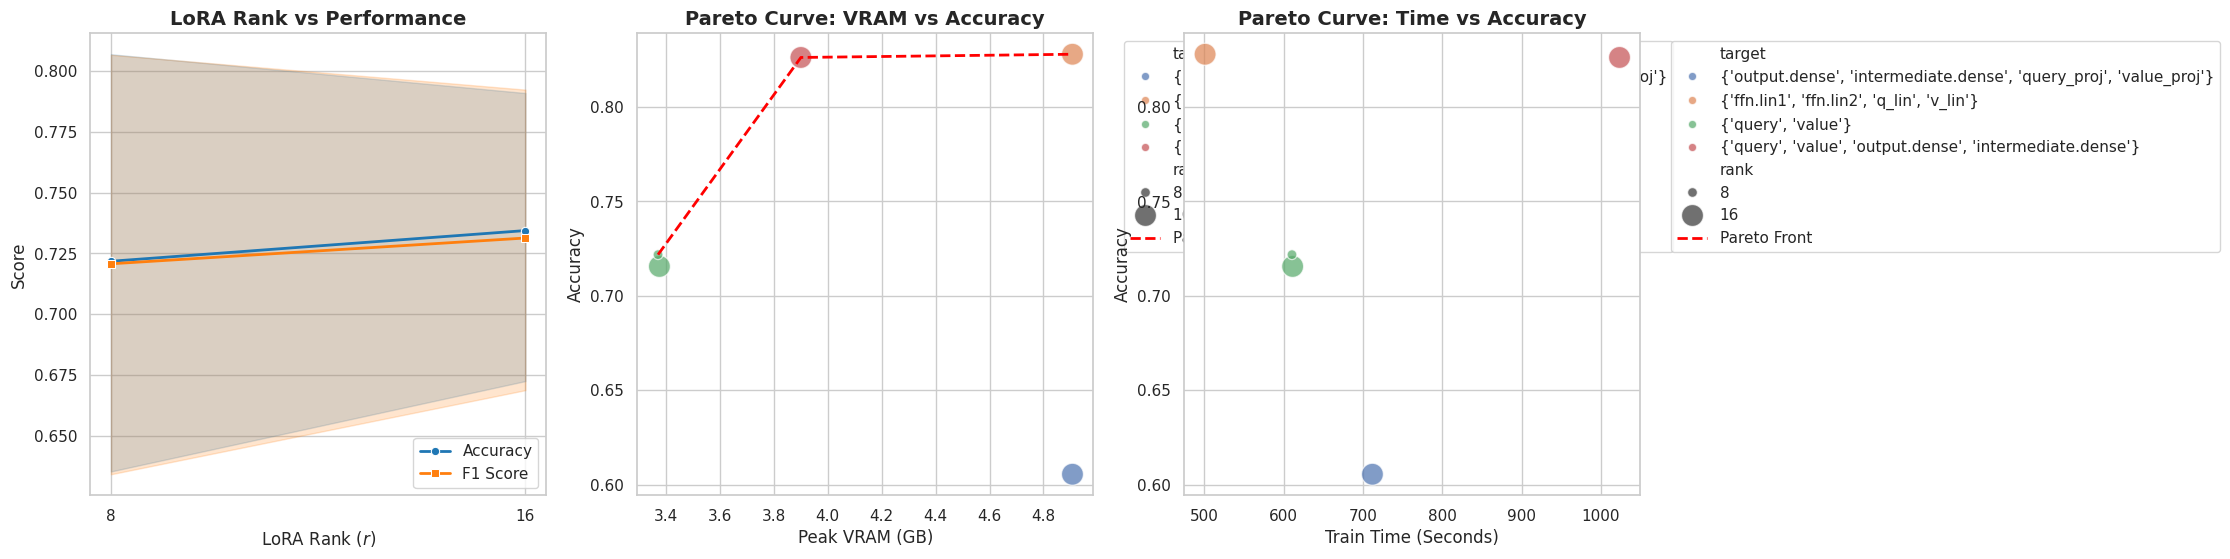

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your logs list is already populated from the training loop
df = pd.DataFrame(logs)

# Set up the plotting framework
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PLOT 1: Rank vs Accuracy/F1 ---
sns.lineplot(data=df, x='rank', y='accuracy', marker='o', ax=axes[0], label='Accuracy', color='#1f77b4', linewidth=2)
sns.lineplot(data=df, x='rank', y='f1', marker='s', ax=axes[0], label='F1 Score', color='#ff7f0e', linewidth=2)
axes[0].set_title('LoRA Rank vs Performance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('LoRA Rank ($r$)', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xscale('log', base=2)

# Ensure x-axis ticks align with standard LoRA ranks (e.g., 4, 8, 16, 32, 64)
ranks = sorted(df['rank'].unique())
axes[0].set_xticks(ranks)
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].legend()

# Helper function to compute the Pareto front
def get_pareto_front(df_agg, x_col, y_col):
    # Sort by X ascending (lower cost), Y descending (higher accuracy)
    sorted_df = df_agg.sort_values(by=[x_col, y_col], ascending=[True, False])
    pareto_front = []
    best_y = -np.inf
    
    for _, row in sorted_df.iterrows():
        if row[y_col] > best_y:
            pareto_front.append(row)
            best_y = row[y_col]
            
    return pd.DataFrame(pareto_front)

# Aggregate by run_name to average out the seeds for a stable Pareto front
df_agg = df.groupby('run_name').agg({
    'vram': 'mean', 
    'train_time': 'mean', 
    'accuracy': 'mean', 
    'rank': 'first', 
    'target': 'first'
}).reset_index()

# --- PLOT 2: Pareto Curve (VRAM vs Accuracy) ---
pareto_vram = get_pareto_front(df_agg, 'vram', 'accuracy')

sns.scatterplot(data=df_agg, x='vram', y='accuracy', hue='target', size='rank', sizes=(50, 250), alpha=0.7, ax=axes[1])
axes[1].plot(pareto_vram['vram'], pareto_vram['accuracy'], color='red', linestyle='--', linewidth=2, label='Pareto Front')
axes[1].set_title('Pareto Curve: VRAM vs Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Peak VRAM (GB)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- PLOT 3: Pareto Curve (Time vs Accuracy) ---
pareto_time = get_pareto_front(df_agg, 'train_time', 'accuracy')

sns.scatterplot(data=df_agg, x='train_time', y='accuracy', hue='target', size='rank', sizes=(50, 250), alpha=0.7, ax=axes[2])
axes[2].plot(pareto_time['train_time'], pareto_time['accuracy'], color='red', linestyle='--', linewidth=2, label='Pareto Front')
axes[2].set_title('Pareto Curve: Time vs Accuracy', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Train Time (Seconds)', fontsize=12)
axes[2].set_ylabel('Accuracy', fontsize=12)
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()